<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Otoño 2025</strong></center>

### Cuerpo Docente:

- Profesores: Stefano Schiappacasse, Sebastián Tinoco
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Angelo Muñoz, Valentina Zúñiga

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Samuel Vejar
- Nombre de alumno 2: David Valenzuela 



### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/...../)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: 6 días de plazo con descuento de 1 punto por día. Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda fuertemente asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"diabetes_data.csv")
df.head(5)
print("Shape del DataFrame:", df.shape)
df.head(5)

Shape del DataFrame: (70692, 18)


,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

=== Información de columnas y tipos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   70692 non-null  float64
 1   Sex                   70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   HeartDiseaseorAttack  70692 non-null  float64
 7   PhysActivity          70692 non-null  float64
 8   Fruits                70692 non-null  float64
 9   Veggies               70692 non-null  float64
 10  HvyAlcoholConsump     70692 non-null  float64
 11  GenHlth               70692 non-null  float64
 12  MentHlth              70692 non-null  float64
 13  PhysHlth              70692 non-null  float64
 14  DiffWalk              70692 no

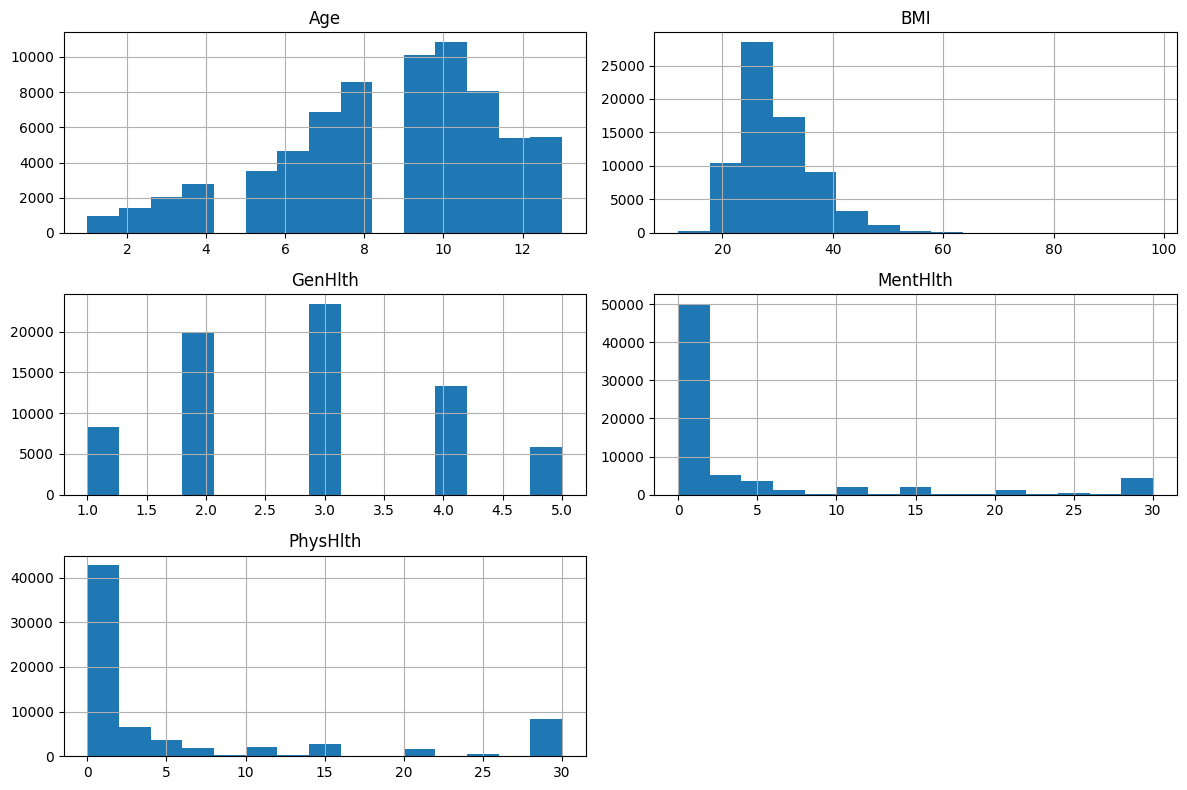

=== Matriz de correlación ===
Diabetes                1.000000
GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Stroke                  0.125427
CholCheck               0.115382
MentHlth                0.087029
Smoker                  0.085999
Sex                     0.044413
Fruits                 -0.054077
Veggies                -0.079293
HvyAlcoholConsump      -0.094853
PhysActivity           -0.158666
Name: Diabetes, dtype: float64 



In [2]:
#Breve exploración 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("=== Información de columnas y tipos ===")
print(df.info(), "\n")

# 3. Valores faltantes por columna
print("=== Valores faltantes ===")
print(df.isnull().sum(), "\n")

# 4. Estadísticas descriptivas de variables numéricas
print("=== Estadísticas descriptivas ===")
print(df.describe(), "\n")

# 5. Conteo de categorías en variables binarias/categóricas
binary_cols = ["Sex","HighChol","CholCheck","Smoker","HeartDiseaseorAttack",
               "PhysActivity","Fruits","Veggies","HvyAlcoholConsump",
               "DiffWalk","Stroke","HighBP","Diabetes"]
for col in binary_cols:
    print(f"--- Distribución en '{col}' ---")
    print(df[col].value_counts(dropna=False), "\n")

# 6. Histograma de distribuciones numéricas
num_cols = ["Age","BMI","GenHlth","MentHlth","PhysHlth"]
df[num_cols].hist(bins=15, figsize=(12,8))
plt.tight_layout()
plt.show()

# 7. Matriz de correlación (para ver relaciones lineales)
corr = df.corr()
print("=== Matriz de correlación ===")
print(corr["Diabetes"].sort_values(ascending=False), "\n")

In [3]:
from sklearn.model_selection import train_test_split

# Separamos características y etiqueta
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

# Split 2/3 train, 1/3 test, manteniendo proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,
    random_state=42,
    stratify=y
)

# Verificamos tamaños
print("Train set:", X_train.shape, y_train.shape)
print("Test set: ", X_test.shape,  y_test.shape)

Train set: (47128, 17) (47128,)
Test set:  (23564, 17) (23564,)


In [4]:
# Inserte su código aquí
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.pipeline import Pipeline

# 1) Listas de variables por tipo
cont_features    = [ "Age", "BMI"]                       # continuas con posibles outliers
health_features  = ["GenHlth", "MentHlth", "PhysHlth"]  # contadores de días de salud
binary_features  = [
    "Sex", "HighChol", "CholCheck", "Smoker", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
    "DiffWalk", "Stroke", "HighBP"
]  # el resto de indicadores binarios

# 2) Pipelines individualizados
# 2a) Escalado robusto para variables continuas
cont_pipeline = Pipeline([
    # RobustScaler usa mediana y rango intercuartílico para atenuar outliers
    ("robust_scaler", StandardScaler())
])

# 2b) Discretización en 3 bins uniformes para contadores de salud
health_pipeline = Pipeline([
    ("kbins", KBinsDiscretizer(
        n_bins=3,               # 3 categorías: bajo, medio, alto
        encode="onehot-dense",  # salida como columnas one-hot
        strategy="uniform"
    ))
])

# 3) Armado del ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cont",   cont_pipeline,   cont_features),
        ("health", health_pipeline, health_features),
        ("bin",    "passthrough",    binary_features),
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")  # salida como pandas.DataFrame

# 4) Ejemplo de ajuste y transformación
preprocessor.fit(X_train)
X_train_proc = preprocessor.transform(X_train)
print("Shape tras preprocesamiento:", X_train_proc.shape)
print(X_train_proc.head())


Shape tras preprocesamiento: (47128, 23)
            Age       BMI  GenHlth_0.0  GenHlth_1.0  GenHlth_2.0  \
70619 -0.203202  0.444135          0.0          1.0          0.0   
69410  0.849124 -0.118240          0.0          0.0          1.0   
51727 -1.255528 -0.118240          0.0          1.0          0.0   
33196 -0.904753  0.162947          0.0          1.0          0.0   
54973  1.199899  0.303541          1.0          0.0          0.0   

       MentHlth_0.0  MentHlth_1.0  MentHlth_2.0  PhysHlth_0.0  PhysHlth_1.0  \
70619           1.0           0.0           0.0           1.0           0.0   
69410           1.0           0.0           0.0           1.0           0.0   
51727           1.0           0.0           0.0           1.0           0.0   
33196           1.0           0.0           0.0           1.0           0.0   
54973           0.0           1.0           0.0           1.0           0.0   

       ...  CholCheck  Smoker  HeartDiseaseorAttack  PhysActivity  Fruits  

In [5]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1) Definimos el pipeline completo: preprocesamiento + XGBoost
pipeline_xgb = Pipeline([
    # Paso 1: preprocesamiento de columnas (el ColumnTransformer que ya creaste)
    ("preprocessor", preprocessor),
    # Paso 2: clasificador XGBoost
    ("clf", XGBClassifier(
        use_label_encoder=False,   # evita warning de versiones antiguas
        eval_metric="logloss",     # métrica interna para XGBoost
        random_state=42
    ))
])

# 2) Entrenamiento del modelo sobre el conjunto de entrenamiento
pipeline_xgb.fit(X_train, y_train)

# 3) Predicción en el conjunto de prueba
y_pred = pipeline_xgb.predict(X_test)

# 4) Evaluación del rendimiento
print("=== Classification Report en Test set ===")
print(classification_report(y_test, y_pred))


=== Classification Report en Test set ===
              precision    recall  f1-score   support

         0.0       0.77      0.70      0.73     11782
         1.0       0.73      0.79      0.75     11782

    accuracy                           0.74     23564
   macro avg       0.75      0.74      0.74     23564
weighted avg       0.75      0.74      0.74     23564



c:\Users\unaro\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [13:52:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


1.Con un accuracy global de 0.74 y un F1-score de 0.73 para la clase no-diabética y 0.75 para la clase diabética, el modelo demuestra un desempeño moderado. Captura correctamente alrededor del 79 % de los casos diabéticos (recall de 0.79) y el 70 % de los no-diabéticos (recall de 0.70). Estos valores indican que el modelo puede servir como un filtro inicial en un escenario clínico, pero aún deja margen para reducir falsos negativos (pacientes con diabetes no detectados) y falsos positivos (etiquetar sanos como diabéticos).

2.– Precision: de todos los casos predichos como positivos (diabéticos), qué proporción realmente lo es. Ayuda a entender la tasa de falsos positivos.
– Recall: de todos los casos positivos reales, qué proporción el modelo identifica. Critica la tasa de falsos negativos.
– F1-score: la media armónica entre precision y recall, equilibrando ambos tipos de error.
– Accuracy: proporción de predicciones correctas en total, pero puede ocultar desequilibrios si una clase domina.

3.No directamente. Las métricas de clasificación miden el desempeño final, pero no revelan si las variables que el modelo utiliza son realmente las más informativas o si ocurren sesgos. Para validar la selección y calidad de las features haríamos falta métodos de interpretabilidad —por ejemplo, Permutation Feature Importance o SHAP values— que cuantifiquen la contribución de cada variable al rendimiento. En ausencia de ese análisis, saber que el accuracy es 0.74 no garantiza que el conjunto de features sea el óptimo, solo que el modelo con esas variables, alcanza ese nivel de rendimiento

## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)

3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

<Figure size 1000x800 with 0 Axes>

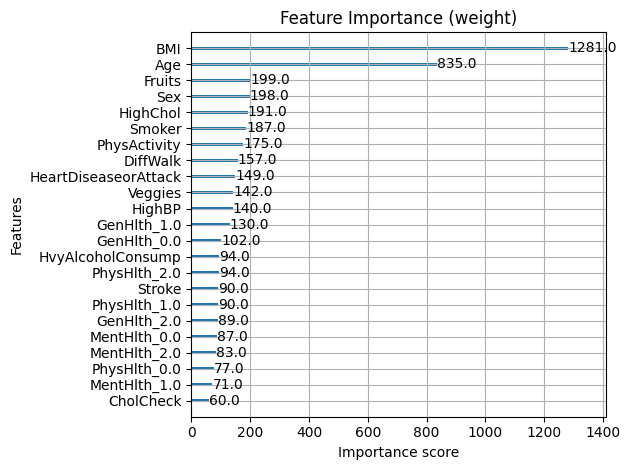

<Figure size 1000x800 with 0 Axes>

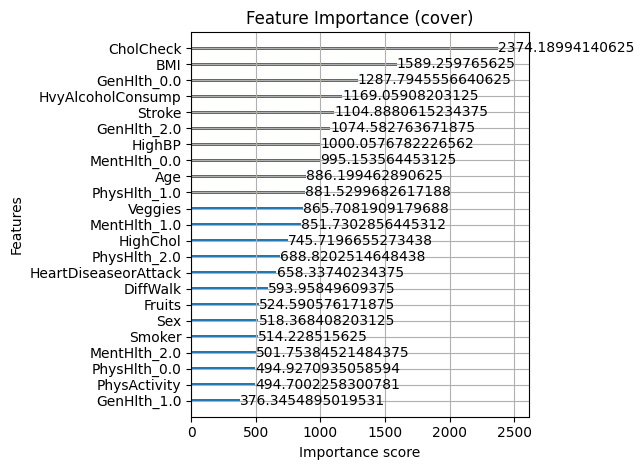

<Figure size 1000x800 with 0 Axes>

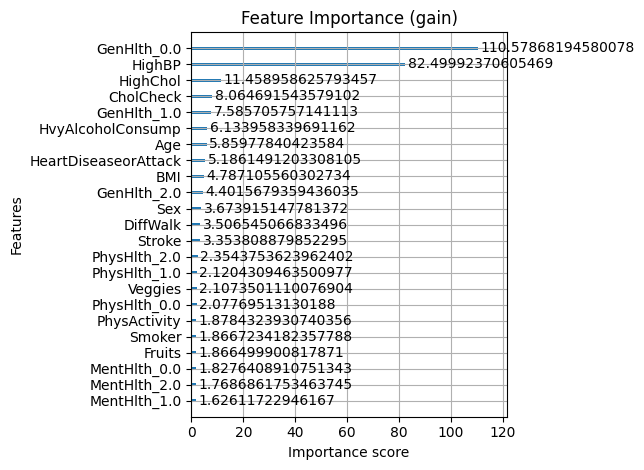

In [6]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Extraer el modelo XGBoost del pipeline
xgb_model = pipeline_xgb.named_steps['clf']

# Para cada tipo de importancia: 'weight', 'cover' y 'gain'
for importance_type in ['weight', 'cover', 'gain']:
    plt.figure(figsize=(10, 8))
    plot_importance(
        xgb_model.get_booster(),
        importance_type=importance_type,
        title=f"Feature Importance ({importance_type})"
    )
    plt.tight_layout()
    plt.show()


## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Respuestas a preguntas

2. Los tres tipos de importancia (weight, cover y gain) muestran cierto solapamiento en las características más relevantes, pero también diferencias, BMI aparece en los dos primeros puestos de weight y cover, lo que indica que se usa con frecuencia y cubre muchas instancias en las divisiones del árbol. Sin embargo, cover destaca adicionalmente a CholCheck, mientras que gain sitúa arriba a GenHlth_0.0 y HighBP, rasgos que aportan el mayor incremento promedio en la función objetivo. Estas desigualdades se deben a que weight mide simplemente cuántas veces se emplea una característica en todas las particiones, cover pondera esa frecuencia por la cantidad de observaciones afectadas, y gain evalúa la mejora promedio de la métrica objetivo al usar esa característica. Así, un rasgo puede usarse muchas veces (weight alto) pero aportar poca ganancia (gain bajo), o viceversa.Aunque los tres métodos resaltan en general similares candidatos (p. ej. BMI y GenHlth_0.0 aparecen en los tres listados, al menos de forma destacada), la ordenación y los valores absolutos difieren porque cada métrica resalta una dimensión distinta de “importancia”. La compatibilidad radica en que todas apuntan a un subconjunto reducido de variables clave, pero la desigualdad en sus rankings subraya que frecuencia de uso, cobertura de datos y ganancia son aspectos complementarios y no intercambiables.

3. estas importancias globales ofrecen una visión rápida de qué variables el modelo utiliza más o mejor, pero no garantizan una interpretabilidad completa. Su principal debilidad es que no capturan la interacción entre características ni el comportamiento local (cómo cambian las predicciones para instancias individuales). Además, pueden sesgarse cuando existen variables correlacionadas o de alta cardinalidad. Para una interpretación más sólida conviene combinar estos rankings con métodos agnósticos locales (como SHAP) que muestren la dirección y magnitud del efecto de cada variable en la predicción.

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

In [7]:
# Inserte su código aquí
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# 1) Preprocesar el set de test
X_test_proc = pipeline_xgb.named_steps['preprocessor'].transform(X_test)
# y_test lo tienes definido desde el train_test_split

# 2) Extraer el clasificador y las names en el orden correcto
clf = pipeline_xgb.named_steps['clf']
feature_names = clf.get_booster().feature_names  # lista en el mismo orden que X_test_proc.columns

# 3) Calcular la accuracy base
y_pred = clf.predict(X_test_proc)
baseline_acc = accuracy_score(y_test, y_pred)

# 4) Para cada feature: permutar su columna y medir caída en accuracy
importances = {}
for feat in feature_names:
    X_perm = X_test_proc.copy()
    # permutamos los valores de la columna
    X_perm[feat] = np.random.permutation(X_perm[feat].values)
    
    y_pred_perm = clf.predict(X_perm)
    perm_acc = accuracy_score(y_test, y_pred_perm)
    
    # la importancia es la diferencia entre baseline y permutada
    importances[feat] = baseline_acc - perm_acc

# 5) Ordenamos de mayor a menor
importances = pd.Series(importances).sort_values(ascending=False)

# 6) Mostramos el resultado
print("Permutation Feature Importances (drop in accuracy):")
print(importances)


Permutation Feature Importances (drop in accuracy):
GenHlth_0.0             0.042947
BMI                     0.030216
Age                     0.027118
HighBP                  0.015362
HighChol                0.012180
GenHlth_1.0             0.005305
HeartDiseaseorAttack    0.003607
DiffWalk                0.003437
CholCheck               0.003268
GenHlth_2.0             0.002843
HvyAlcoholConsump       0.002037
PhysHlth_1.0            0.001570
PhysActivity            0.001103
Veggies                 0.000806
Smoker                  0.000594
Stroke                  0.000509
MentHlth_1.0            0.000255
Sex                     0.000127
PhysHlth_2.0           -0.000127
MentHlth_0.0           -0.000127
Fruits                 -0.000552
PhysHlth_0.0           -0.000806
MentHlth_2.0           -0.000934
dtype: float64


Desviación estándar de importancias por feature:
Age                     0.002117
GenHlth_0.0             0.001918
BMI                     0.001789
HighBP                  0.001641
HighChol                0.001303
HeartDiseaseorAttack    0.000842
DiffWalk                0.000749
GenHlth_2.0             0.000733
GenHlth_1.0             0.000724
Sex                     0.000679
CholCheck               0.000638
Fruits                  0.000631
PhysActivity            0.000592
Veggies                 0.000587
HvyAlcoholConsump       0.000583
MentHlth_0.0            0.000538
PhysHlth_2.0            0.000505
Smoker                  0.000474
PhysHlth_1.0            0.000435
Stroke                  0.000423
PhysHlth_0.0            0.000405
MentHlth_2.0            0.000344
MentHlth_1.0            0.000308
dtype: float64


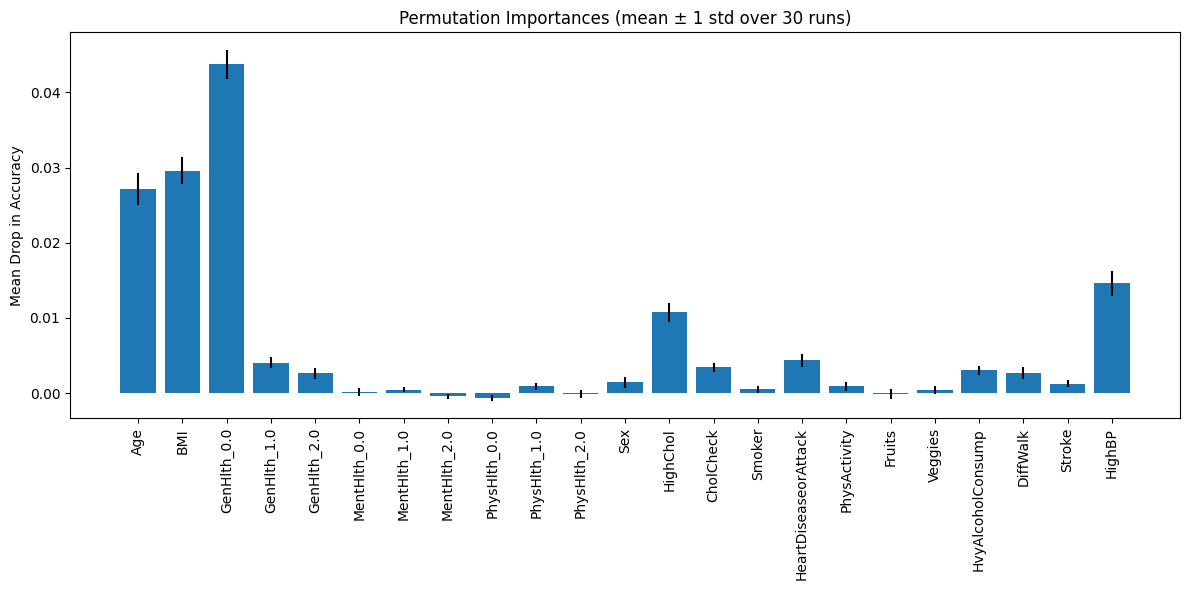

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1) Preprocesamiento único del set de prueba
X_test_proc = pipeline_xgb.named_steps['preprocessor'].transform(X_test)
y_true      = y_test.values
clf         = pipeline_xgb.named_steps['clf']
feature_names = clf.get_booster().feature_names

# 2) Accuracy base (sin permutar)
baseline_acc = accuracy_score(y_true, clf.predict(X_test_proc))

# 3) Repetir permutaciones
n_runs = 30
importances = pd.DataFrame(index=feature_names, columns=range(n_runs))

for run in range(n_runs):
    imps = {}
    # comenzamos de nuevo con datos limpios
    X_base = X_test_proc.copy()
    for feat in feature_names:
        X_perm = X_base.copy()
        X_perm[feat] = np.random.permutation(X_base[feat].values)
        acc_perm = accuracy_score(y_true, clf.predict(X_perm))
        imps[feat] = baseline_acc - acc_perm
    importances[run] = pd.Series(imps)

# 4) Estadísticas
mean_imp = importances.mean(axis=1)
std_imp  = importances.std(axis=1)

print("Desviación estándar de importancias por feature:")
print(std_imp.sort_values(ascending=False))

# 5) Visualización
plt.figure(figsize=(12,6))
plt.bar(mean_imp.index, mean_imp.values, yerr=std_imp.values)
plt.xticks(rotation=90)
plt.ylabel('Mean Drop in Accuracy')
plt.title('Permutation Importances (mean ± 1 std over 30 runs)')
plt.tight_layout()
plt.show()


1. El método de Permutation Feature Importance cuantifica la relevancia de cada variable midiendo cuánto cae la métrica de desempeño (en este caso, accuracy) cuando “rompemos” su relación con la etiqueta. Para ello, permutamos aleatoriamente los valores de una característica en el set de prueba, volvemos a predecir y calculamos la diferencia entre la precisión original y la nueva precisión. Esa diferencia promedio sobre múltiples corridas nos da el “drop in accuracy” atribuible a cada feature, es decir, su contribución global al modelo.

2. 
Las cinco variables con mayor caída media en accuracy son:
GenHlth_0.0 (0.043),el bin de peor salud general, lo cual es lógico porque la autopercepción de mala salud está muy ligada al riesgo de diabetes.BMI (0.031) índice de masa corporal alto es un factor de riesgo bien documentado para diabetes. Age (0.026),la edad  incrementa la probabilidad de desarrollar diabetes.HighBP (0.013) la hipertensión suele coexistir con síndrome metabólico, incluidas alteraciones de la glucemia.HighChol (0.013): el colesterol alto también refleja trastornos metabólicos asociados a resistencia a la insulina.Todas estas variables coinciden con factores de riesgo clínicos conocidos, por lo que su posición en el ranking tiene pleno sentido.

3.

Ventajas:

Agnóstico al modelo: funciona con cualquier caja negra siempre que se puedan obtener predicciones.

Intuitivo y directo: la métrica resultante (caída en accuracy) es fácil de interpretar.

Captura interacciones: al medir desempeño global sí refleja efectos combinados de variables correlacionadas o con interacciones.

Desventajas:

Sesgo por correlación: variables muy correlacionadas pueden repartir su importancia, infravalorando ambas.

Costo computacional: requiere repetir predicciones tantas veces como features y corridas, lo que puede ser lento en datasets grandes.

Dependencia de la métrica: el ranking cambia según la métrica elegida (accuracy, AUC, etc.) y del set de validación empleado, por lo que no es universalmente estable.

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

Respuesta:

2. Cada shapValue representa la contribución de la característica de manera individual a la predicción. 
3. Sí, En este caso de clasificación postivio es una contribución a predecir la clase positiva, negativo es contribución a predecir la clase negativa.



In [9]:
import shap
model = pipeline_xgb.named_steps['clf']
preprocessor = pipeline_xgb.named_steps['preprocessor']
explainer = shap.TreeExplainer(model, feature_names=preprocessor.get_feature_names_out())
X_train_proc = preprocessor.transform(X_train)
shap_values = explainer(X_train_proc)

### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

Respuestas:
* GenHlth, edad, HighBP, HighChol.
* El patrón comun es que GenHlth es siempre bajo y HighBP alto siempre aportan a predecir diabetes.
* Por ahora no, No tenemmos un % de coverage solo 3 datos. Faltaría hacer un análisis global sobre los Shape Values para poder tener más certeza.

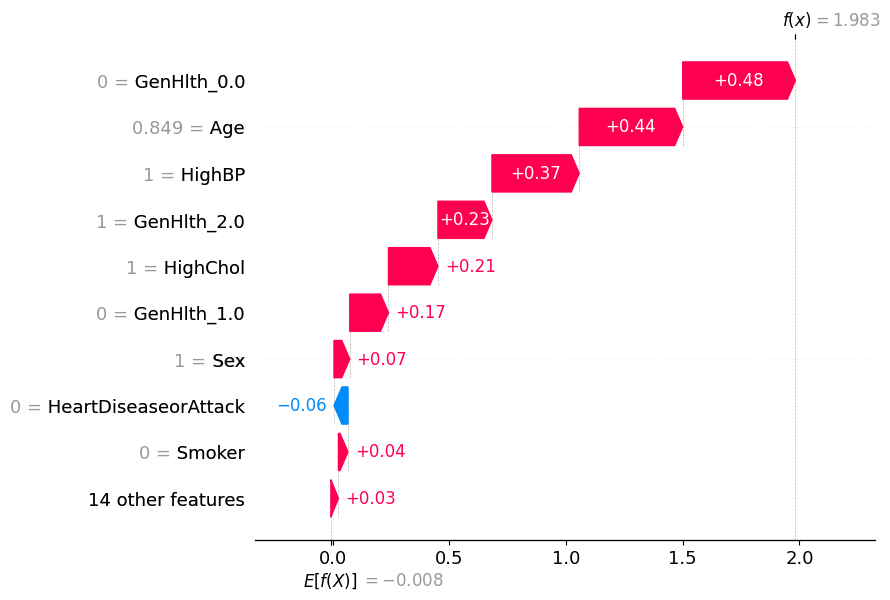

In [10]:
# Inserte código para generar gráficos de aporte local aquí
shap.plots.waterfall(shap_values[1, :], max_display=10)

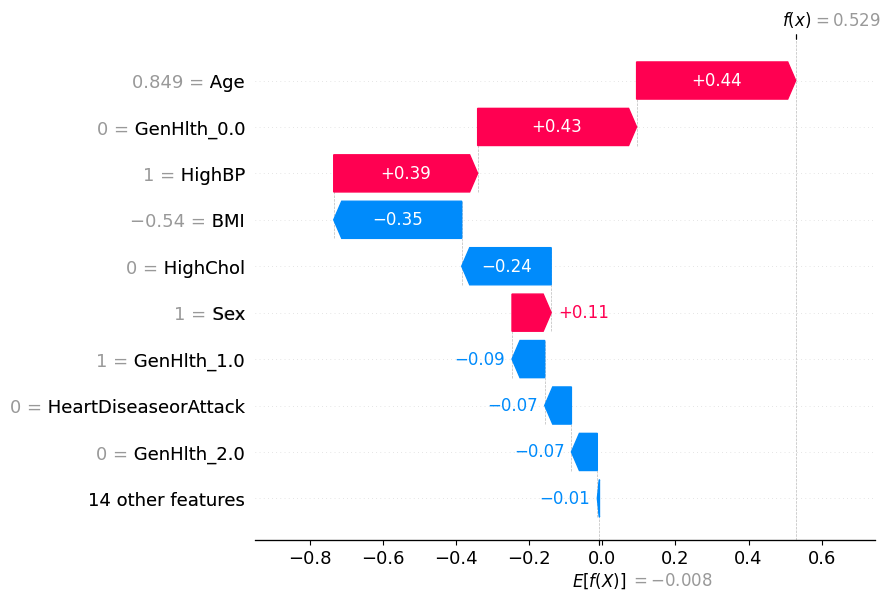

In [11]:
shap.plots.waterfall(shap_values[9, :], max_display=10)

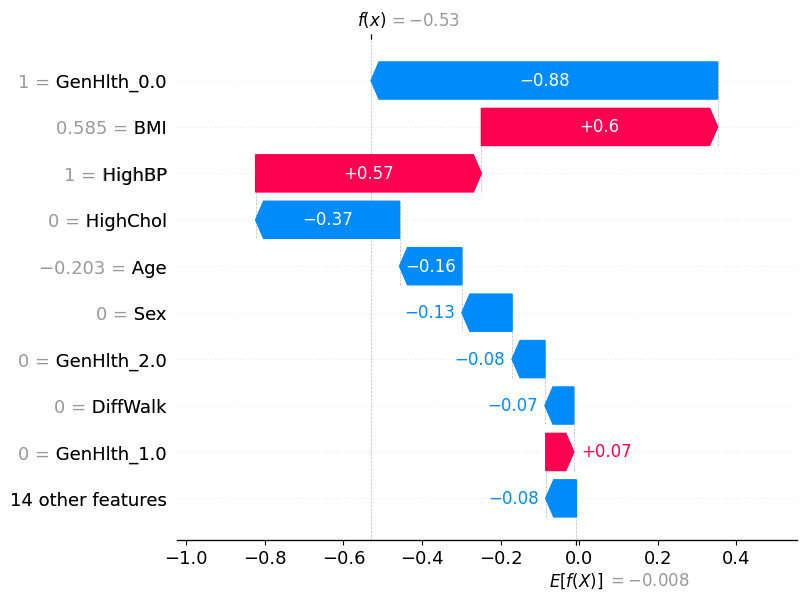

In [12]:
shap.plots.waterfall(shap_values[150, :], max_display=10)

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

Respuesta:
* En general, hay diferencias en la importancia de cada feature a nivel local, lo que es esperable dado que dependiendo del valor que algunos datos tomen, su contribución va a variar. De todas formas, los principales contribuyentes son GenHlth_0.0 (en 0), highBP, BMI y Age. Lo que a priori tiene sentido con el conocimiento general sobre la diabetes. 

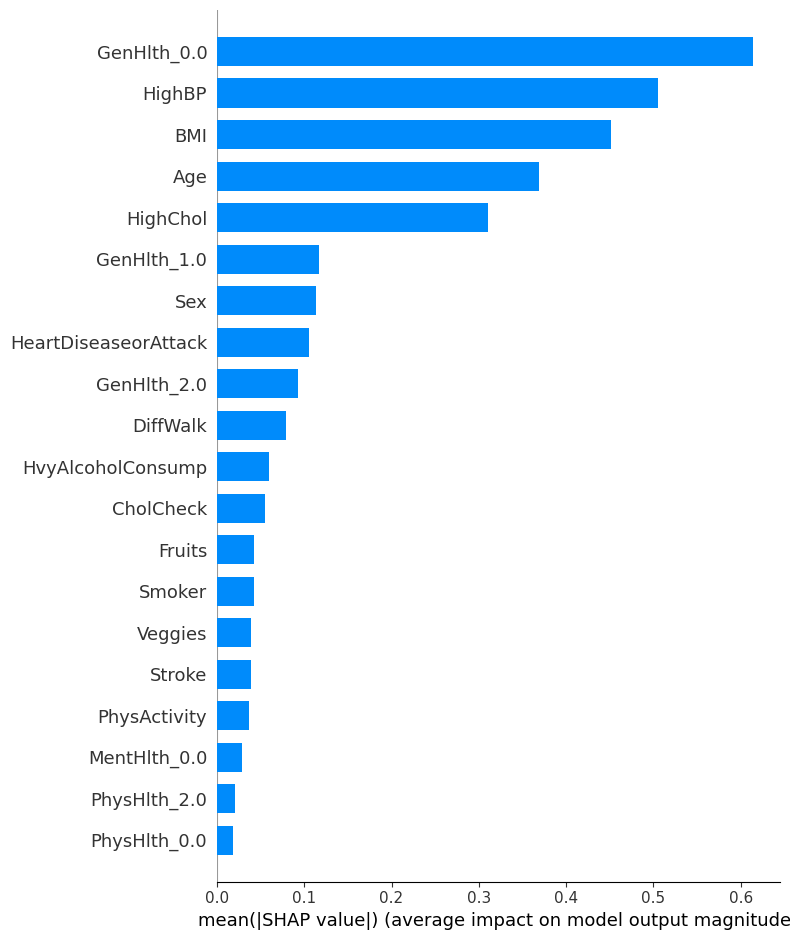

In [13]:
# Inserte código para generar gráficos de aporte global aquí
shap.summary_plot(shap_values, X_test_proc, feature_names=preprocessor.get_feature_names_out(), plot_type="bar")


### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

Respuesta:

1. GenHlth_0.0 varia su contribución dependiendo de si es 0 o 1, pero en general cuando es 0 tiene un valor mas alto.
2. HighBP cuando es 1 aporta notablemente a la clase positiva, cunado es 0 a la clase negativa
3. BMI Tiene una tendencia al alza cuando aumenta hasta aproximadamente elñ  valor 4. En general cuando contribuye a la clase positiva la predicción tiene una alta probabilidad.
4. Para la edad existe un comportamiento análogo a BMI.
5. Cuando es 0 suele contribuir a la clase negativa y la probabilidad negativa tiende a ser alta, lo contrario para cuando toma el valor de 1.

In [14]:
# DataFrame con valores SHAP
shap_df = pd.DataFrame(shap_values.values, columns=shap_values.feature_names)

# Media del valor absoluto por feature
mean_abs_shap = np.abs(shap_df).mean().sort_values(ascending=False)

# Top 5 features
top5_features = mean_abs_shap.head(5).index.tolist()
print("Top 5 features por valor absoluto medio de SHAP:")
print(top5_features)
y_proba = model.predict_proba(X_train_proc)[:, 1]

Top 5 features por valor absoluto medio de SHAP:
['GenHlth_0.0', 'HighBP', 'BMI', 'Age', 'HighChol']


In [15]:
y_proba

array([0.6629458 , 0.87897253, 0.44322634, ..., 0.7002337 , 0.6128409 ,
       0.33278364], dtype=float32)

GenHlth_0.0


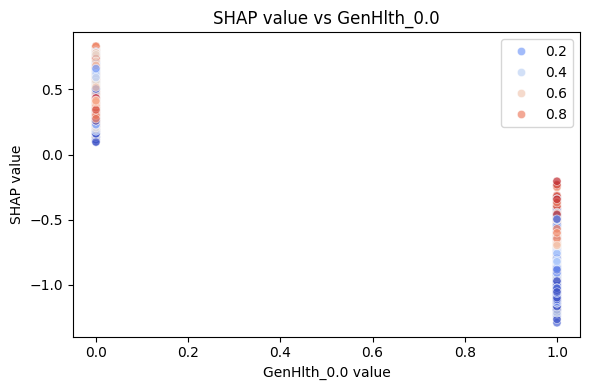

HighBP


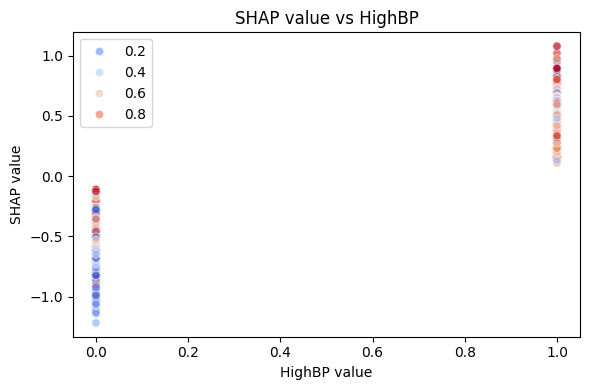

BMI


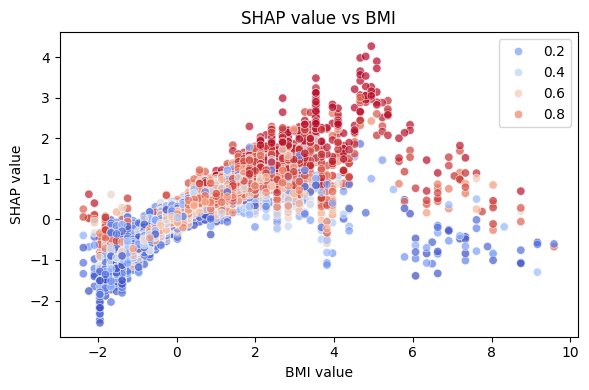

Age


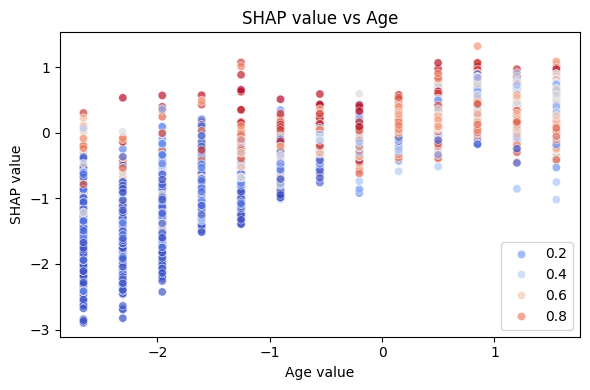

HighChol


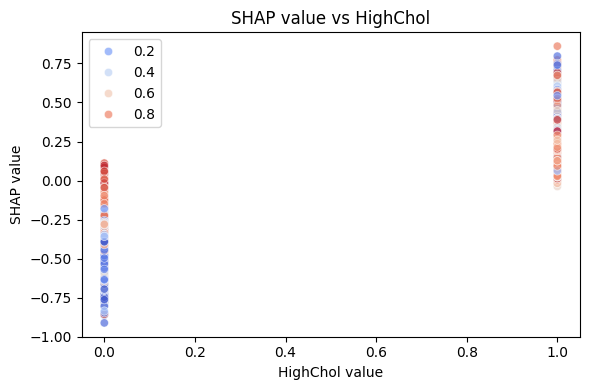

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una figura por feature
for feature in top5_features:
    print(feature)
    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        x=X_train_proc[feature].values,                     
        y=shap_df[feature].values,              
        hue=y_proba,                     
        palette='coolwarm',
        alpha=0.7
    )
    plt.title(f'SHAP value vs {feature}')
    plt.xlabel(f'{feature} value')
    plt.ylabel('SHAP value')
    plt.tight_layout()
    plt.show()


### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

Respuesta:
- Las relaciones que se pueden concluir son similares a los de scatter, en general la tendencia es aumentar, excpeto en GenHlt_0.0. 
- No es generalizable al conjunto de datos porque este análisis es sobre cambios en el modelo y no la distribución de los datos en si.

In [17]:
X_train_proc

,Age,BMI,GenHlth_0.0,GenHlth_1.0,GenHlth_2.0,MentHlth_0.0,MentHlth_1.0,MentHlth_2.0,PhysHlth_0.0,PhysHlth_1.0,...,CholCheck,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,DiffWalk,Stroke,HighBP
70619,-0.203202,0.444135,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
69410,0.849124,-0.118240,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
51727,-1.255528,-0.118240,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
33196,-0.904753,0.162947,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
54973,1.199899,0.303541,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59938,0.849124,1.006510,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
41054,0.147573,-0.680616,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
69682,-0.203202,0.444135,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
17655,1.199899,-0.399428,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [18]:
# Parametros para el PDP
common_params = {
    "n_jobs": 2,
    "grid_resolution": 20,
    "random_state": 0,
    "subsample": 1000,
}

# características a analizar
features_info = {
    # features of interest
    "features":  ['GenHlth', 'HighBP', 'BMI', 'Age', 'HighChol'],
    # type of partial dependence plot
    "kind": "average",
    # information regarding categorical features
    "categorical_features":  ['GenHlth', 'HighBP', 'HighChol'],
}

In [19]:
pipeline_xgb.fit(X_train, y_train)

c:\Users\unaro\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [13:53:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cont',
                                                  Pipeline(steps=[('robust_scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BMI']),
                                                 ('health',
                                                  Pipeline(steps=[('kbins',
                                                                   KBinsDiscretizer(encode='onehot-dense',
                                                                                    n_bins=3,
                                                                                    strategy='uniform'))]),
                                                  ['GenHlth', 'MentHlth',
                                                   'PhysHlth']),
                                                 ('bin', 'passthrough',
                                                  ['Sex', 'HighChol',
                                                   'CholCheck', 'Smoker',
                                                   'HeartDis...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

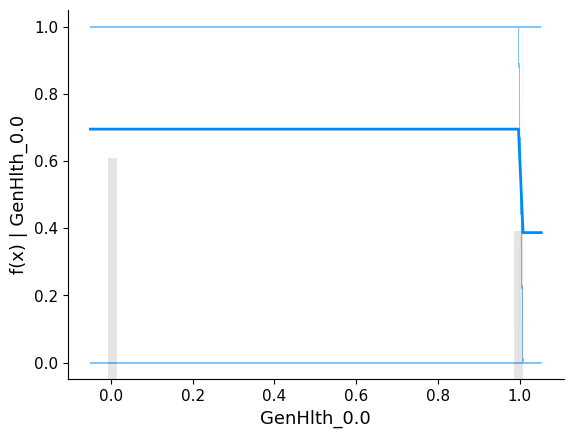

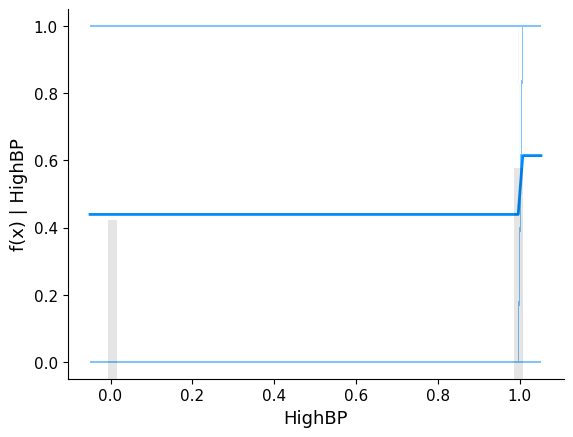

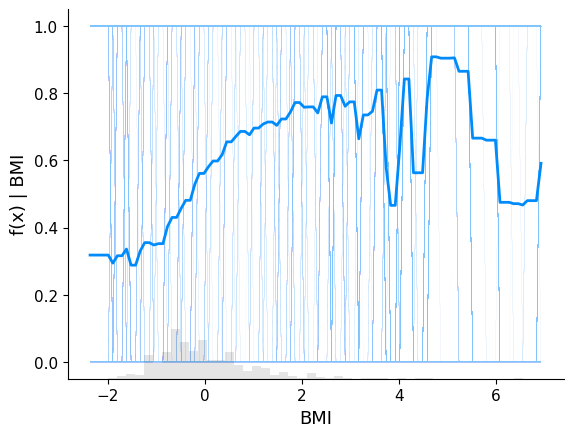

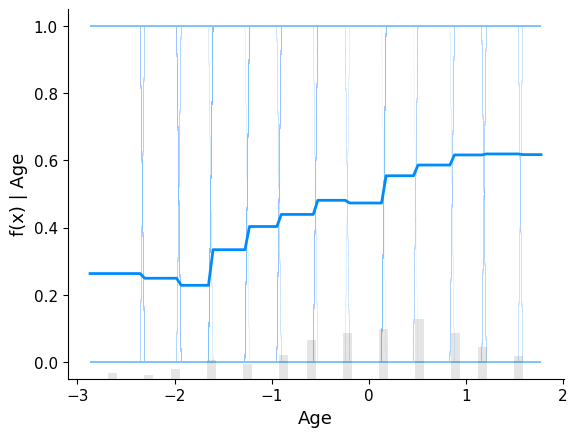

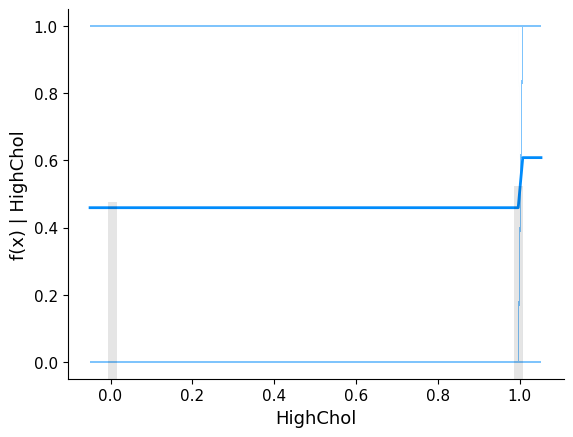

In [38]:
cols = ['GenHlth_0.0', 'HighBP', 'BMI', 'Age', 'HighChol']
X_1000 = shap.sample(X_train_proc, 1000) 
for col in cols:
    shap.plots.partial_dependence(
        ind=col,
        model=clf.predict,
        data=X_1000,
        ice=True,
        ace_opacity=0.3,
        pd_opacity=1.0
    )

## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

Respuesta:

* El que tiene mejor coverage es la regla que aplica sobre salud general 0, lo que tiene sentido pues es de conocimiento general que diabetes es una enfermedad que es posible desarrollar con malos hábitos de salud. Pero esto no generaliza al universo entero de detecciones de diabetes, como la genética.

In [21]:
from alibi.explainers import AnchorTabular

In [39]:
# Inserte su código para generar sistema de reglas aquí
explainer = AnchorTabular( lambda x: clf.predict(x), clf.feature_names_in_, seed = 0)
explainer.fit(X_train_proc.to_numpy())


AnchorTabular(meta={
  'name': 'AnchorTabular',
  'type': ['blackbox'],
  'explanations': ['local'],
  'params': {'seed': 0, 'disc_perc': (25, 50, 75)}}
)

In [41]:
for idx in [1000, 3001, 5751]:

    obs = np.array(X_test_proc.iloc[idx], ndmin=2)
    explanation = explainer.explain(X_test_proc.iloc[idx].to_numpy(), threshold=0.95)

    print(f"=== Predicción idx : {idx}===")
    print("Predicción:", explainer.predictor(X_test_proc.to_numpy()[idx].reshape(1, -1))[0])
    print("Anchor : ", explanation.anchor)
    print("Precision : ", explanation.precision)
    print("Coverage : ", explanation.coverage)


=== Predicción idx : 1000===
Predicción: 1
Anchor :  ['GenHlth_0.0 <= 0.00', 'DiffWalk > 0.00', 'BMI > -0.68', 'Age > 0.15']
Precision :  0.9891304347826086
Coverage :  0.4201748429808182
=== Predicción idx : 3001===
Predicción: 1
Anchor :  ['GenHlth_0.0 <= 0.00', 'HighBP > 0.00', 'Age > 0.15', 'BMI > -0.68']
Precision :  0.9853587115666179
Coverage :  0.4201748429808182
=== Predicción idx : 5751===
Predicción: 1
Anchor :  ['GenHlth_0.0 <= 0.00', 'HeartDiseaseorAttack > 0.00']
Precision :  0.9536585365853658
Coverage :  0.5992403666610083


# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

> Fundamente su Respuesta aquí

- Los métodos globales dieron idicios de qué estaba aportando cada feature a la predicción del modelo y fue muy útil ver que tener un estado de salud malo de base (Ghlth_0.0 y BMI alto, y HBP), en general, es un indicio de diabetes. lo que concuerda con el conocimiento general sobre la diabetes, pero también sabemos que no todas las personas en mal estado de salud desarrollan diabetes.

- Los métodos locales que utilizamos nos ayudaron a enteder qué estaba contribuyendo a la predicción dada por el modelo, lo que puede servir para investigar los Falsos positivos y Falsos negativos. También da una forma de explicarle a un paciente por qué creemos que es probable que tenga la enfermedad. 

En el caso del Dr. Simi, métodos locales le puede ser más útil, pues las causas de la enfermad están estudiades y las conclusiones globales pueden llegar a ser redundantes. En este sentido, una explicación de porque su paciente está en el grupo de riesgo le es más útil.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>